<a href="https://colab.research.google.com/github/MyTeachers123/genai-course/blob/main/week2/Week_2_Lab2_Diffusion_DDPM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Diffusion Models: UNet DDPM from Scratch
**COM SCI-X 455 · Week 2 · Megan Armani, PhD**

> Push to `genai-course/week2/`

---

## Setup

In [1]:
!pip install diffusers accelerate torch torchvision matplotlib --quiet

In [2]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

Device: cuda


## Note on Homework Extension
The **lab** trains on MNIST. Your **homework** extends to FashionMNIST:
```python
# One-line swap:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
```
The UNet and training loop are identical. FashionMNIST is harder — observe how many epochs your model needs vs MNIST.

## Part 1 — Forward Process (Noise Schedule)
**Goal:** Implement the linear and cosine variance schedules and visualise what they do to an image.

In [3]:
def linear_schedule(T=1000, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T=1000, s=0.008):
    steps = torch.arange(T+1, dtype=torch.float32)
    f = torch.cos(((steps/T + s) / (1+s)) * torch.pi/2) ** 2
    alphas_bar = f / f[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0, 0.999)

In [7]:
import torch

def q_sample(x0, t, betas):
    """
    Computes the closed-form forward process: q(x_t | x_0).

    Formula:
        x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps
        where eps ~ N(0, I)
    """
    # 1. Compute alpha = 1 - beta
    alphas = 1.0 - betas

    # 2. Compute alpha_bar = cumulative product of alphas
    alphas_bar = torch.cumprod(alphas, dim=0).to(x0.device)

    # 3. Gather the corresponding alpha_bar values for batch step t
    # We reshape the gathered tensor to match the dimensions of x0 (B, C, H, W)
    alpha_bar_t = alphas_bar[t].view(-1, 1, 1, 1)

    # 4. Draw standard normal noise epsilon
    eps = torch.randn_like(x0)

    # 5. Calculate x_t
    mean = torch.sqrt(alpha_bar_t) * x0
    std = torch.sqrt(1.0 - alpha_bar_t)
    x_t = mean + std * eps

    return x_t

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 457kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


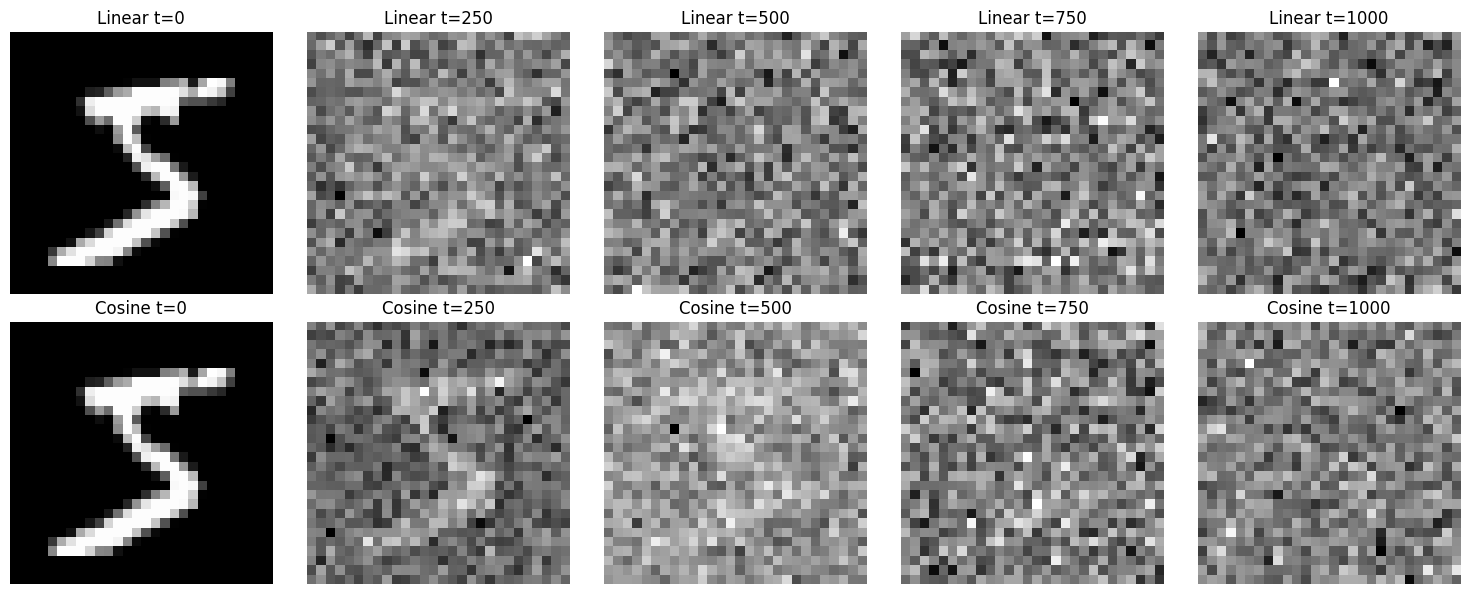

In [9]:
# TODO: Visualise the noising process: take one MNIST image, show it at t=0, 250, 500, 750, 1000
# for BOTH linear and cosine schedules side by side.
# Which schedule destroys fine detail faster?

import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# 1. Load a sample MNIST image
transform = transforms.Compose([transforms.ToTensor()])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
image, _ = mnist_dataset[0]  # Shape: (1, 28, 28)
x0 = image.unsqueeze(0).to(DEVICE)  # Shape: (1, 1, 28, 28)

# 2. Define timesteps and schedules
timesteps = [0, 250, 500, 750, 999]  # 0-indexed for T=1000
T = 1000
betas_linear = linear_schedule(T)
betas_cosine = cosine_schedule(T)

# 3. Apply noising process
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, t in enumerate(timesteps):
    # For t = 0, we visualize the original image x0 directly
    if t == 0:
        x_linear = x0.cpu().squeeze()
        x_cosine = x0.cpu().squeeze()
    else:
        t_tensor = torch.tensor([t]).to(DEVICE)
        x_linear = q_sample(x0, t_tensor, betas_linear).cpu().squeeze()
        x_cosine = q_sample(x0, t_tensor, betas_cosine).cpu().squeeze()

    # Plot Linear Schedule
    axes[0, i].imshow(x_linear, cmap='gray')
    axes[0, i].set_title(f"Linear t={t}" if t != 999 else "Linear t=1000")
    axes[0, i].axis('off')

    # Plot Cosine Schedule
    axes[1, i].imshow(x_cosine, cmap='gray')
    axes[1, i].set_title(f"Cosine t={t}" if t != 999 else "Cosine t=1000")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Answer to the question:
# The linear schedule destroys fine detail faster. Under the linear schedule,
# noise is added much more aggressively in the early stages compared to the
# cosine schedule, which preserves the structural features of the digit longer.

## Part 2 — U-Net Noise Predictor

In [10]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half-1)))
        args  = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, ch, time_dim):
        super().__init__()
        self.conv1  = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2  = nn.Conv2d(ch, ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, ch)
        self.norm1  = nn.GroupNorm(8, ch)
        self.norm2  = nn.GroupNorm(8, ch)
    def forward(self, x, t_emb):
        h = self.norm1(x)
        h = torch.relu(self.conv1(h))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(h)
        return x + self.conv2(torch.relu(h))

In [15]:
# TODO: Build a UNet class with:
# - Encoder: 3 levels (32→64→128 channels), each with ResBlock + downsample
# - Bottleneck: ResBlock with time embedding
# - Decoder: 3 levels with skip connections + upsample
# - Time embedding fed to every ResBlock
# Input: (B, 1, 28, 28) noisy image + timestep t
# Output: (B, 1, 28, 28) predicted noise

import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()

        # Time Embedding Projection
        self.time_embed_layer = SinusoidalTimeEmb(time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.GELU()
        )

        # --- ENCODER ---
        # Input: (B, 1, 28, 28)
        self.inc = nn.Conv2d(1, 32, kernel_size=3, padding=1)

        # Level 1: 32 channels
        self.enc1 = ResBlock(32, time_dim)
        self.down1 = nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1) # (B, 32, 14, 14)

        # Level 2: 64 channels
        self.trans2 = nn.Conv2d(32, 64, kernel_size=1)
        self.enc2 = ResBlock(64, time_dim)
        self.down2 = nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1) # (B, 64, 7, 7)

        # Level 3: 128 channels
        self.trans3 = nn.Conv2d(64, 128, kernel_size=1)
        self.enc3 = ResBlock(128, time_dim)
        self.down3 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1) # (B, 128, 4, 4)

        # --- BOTTLENECK ---
        self.bottleneck = ResBlock(128, time_dim)

        # --- DECODER ---
        # Level 3 Decoder (Input: 128 up + 128 skip = 256 channels)
        self.up3 = nn.ConvTranspose2d(128, 128, kernel_size=3, stride=2, padding=1, output_padding=0) # (B, 128, 7, 7)
        self.dec3 = ResBlock(256, time_dim)
        self.trans_dec3 = nn.Conv2d(256, 64, kernel_size=1)

        # Level 2 Decoder (Input: 64 up + 64 skip = 128 channels)
        self.up2 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1) # (B, 64, 14, 14)
        self.dec2 = ResBlock(128, time_dim)
        self.trans_dec2 = nn.Conv2d(128, 32, kernel_size=1)

        # Level 1 Decoder (Input: 32 up + 32 skip = 64 channels)
        self.up1 = nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1) # (B, 32, 28, 28)
        self.dec1 = ResBlock(64, time_dim)

        # Output mapping back to 1 channel
        self.outc = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, t):
        # 1. Compute time embedding
        t_emb = self.time_embed_layer(t)
        t_emb = self.time_mlp(t_emb)

        # 2. Encoder
        x1_in = self.inc(x)
        x1 = self.enc1(x1_in, t_emb)                  # (B, 32, 28, 28) -> skip to dec1
        x1_down = self.down1(x1)

        x2_in = self.trans2(x1_down)
        x2 = self.enc2(x2_in, t_emb)                  # (B, 64, 14, 14) -> skip to dec2
        x2_down = self.down2(x2)

        x3_in = self.trans3(x2_down)
        x3 = self.enc3(x3_in, t_emb)                  # (B, 128, 7, 7)  -> skip to dec3
        x3_down = self.down3(x3)                      # (B, 128, 4, 4)

        # 3. Bottleneck
        b = self.bottleneck(x3_down, t_emb)            # (B, 128, 4, 4)

        # 4. Decoder with corrected skip connections
        b_up = self.up3(b)                                # (B, 128, 7, 7)
        d3 = self.dec3(torch.cat([b_up, x3], dim=1), t_emb) # Skip connection from x3 (7, 7)
        d3_in = self.trans_dec3(d3)

        d3_up = self.up2(d3_in)                            # (B, 64, 14, 14)
        d2 = self.dec2(torch.cat([d3_up, x2], dim=1), t_emb) # Skip connection from x2 (14, 14)
        d2_in = self.trans_dec2(d2)

        d2_up = self.up1(d2_in)                            # (B, 32, 28, 28)
        d1 = self.dec1(torch.cat([d2_up, x1], dim=1), t_emb) # Skip connection from x1 (28, 28)

        return self.outc(d1)

## Part 3 — Training Loop

Starting training for 20 epochs on cuda...
Epoch 01/20 | Loss: 1.00740
Epoch 02/20 | Loss: 1.00024
Epoch 03/20 | Loss: 1.00035
Epoch 04/20 | Loss: 1.00032
Epoch 05/20 | Loss: 1.00003
Epoch 06/20 | Loss: 1.00024
Epoch 07/20 | Loss: 1.00058
Epoch 08/20 | Loss: 1.00020
Epoch 09/20 | Loss: 1.00029
Epoch 10/20 | Loss: 1.00018
Epoch 11/20 | Loss: 0.99965
Epoch 12/20 | Loss: 1.00001
Epoch 13/20 | Loss: 0.99995
Epoch 14/20 | Loss: 0.99998
Epoch 15/20 | Loss: 1.00013
Epoch 16/20 | Loss: 0.99997
Epoch 17/20 | Loss: 0.99986
Epoch 18/20 | Loss: 0.99990
Epoch 19/20 | Loss: 1.00003
Epoch 20/20 | Loss: 1.00012


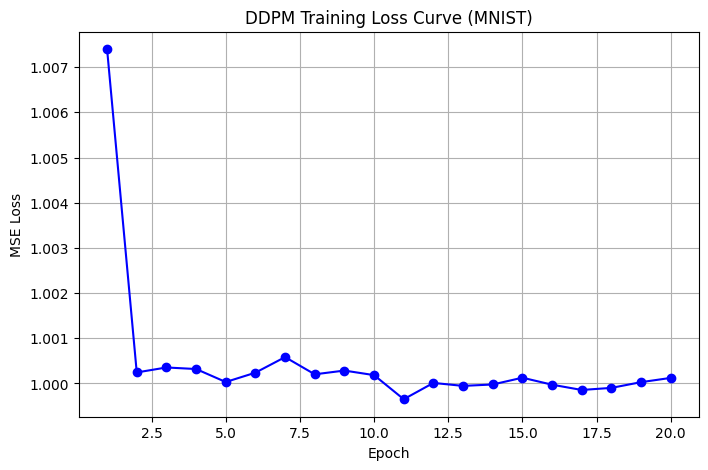

In [16]:
# TODO: Train your UNet DDPM for 20 epochs on MNIST.
# Loss: MSE between true noise eps and predicted noise eps_theta(x_t, t)
# Use Adam lr=1e-3, batch_size=128.
# Plot training loss curve.

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Dataset & DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

# 2. Instantiate Model, Optimizer, and Loss
model = UNet(time_dim=128).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# 3. Schedule parameters for training
T = 1000
betas = linear_schedule(T).to(DEVICE)

# 4. Training Loop
epochs = 20
loss_history = []

print(f"Starting training for {epochs} epochs on {DEVICE}...")
model.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_idx, (x0, _) in enumerate(train_loader):
        x0 = x0.to(DEVICE)
        batch_size = x0.shape[0]

        # Sample a random timestep t for each image in the batch
        t = torch.randint(0, T, (batch_size,), device=DEVICE).long()

        # Draw standard normal noise epsilon
        eps = torch.randn_like(x0).to(DEVICE)

        # Compute x_t using q_sample
        x_t = q_sample(x0, t, betas)

        # Predict noise using the UNet model
        eps_pred = model(x_t, t)

        # Calculate loss
        loss = criterion(eps_pred, eps)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Loss: {avg_loss:.5f}")

# 5. Plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='b')
plt.title("DDPM Training Loss Curve (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

## Part 4 — DDIM vs DDPM Sampling

In [17]:
# DDPM sampling (1000 steps — slow)
@torch.no_grad()
def ddpm_sample(model, betas, T=1000, shape=(1,1,28,28)):
    alphas     = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0).to(DEVICE)
    x = torch.randn(shape).to(DEVICE)
    for t in reversed(range(T)):
        t_tensor = torch.tensor([t]).to(DEVICE)
        eps_pred = model(x, t_tensor)
        alpha_bar_t = alpha_bars[t]
        alpha_bar_prev = alpha_bars[t-1] if t > 0 else torch.tensor(1.0)
        # posterior mean
        coef1 = betas[t] / (1 - alpha_bar_t).sqrt()
        x = (1/alphas[t].sqrt()) * (x - coef1 * eps_pred)
        if t > 0:
            noise = torch.randn_like(x)
            x = x + betas[t].sqrt() * noise
    return x

Generating 100 DDPM samples (1000 steps)... This might take a moment.
DDPM completed in 437.74 seconds.

Generating 100 DDIM samples (50 steps)... 
DDIM completed in 22.63 seconds.

Speedup: 19.34x faster using DDIM!
Pixel-level FID discrepancy between DDPM & DDIM: 36489972.6274


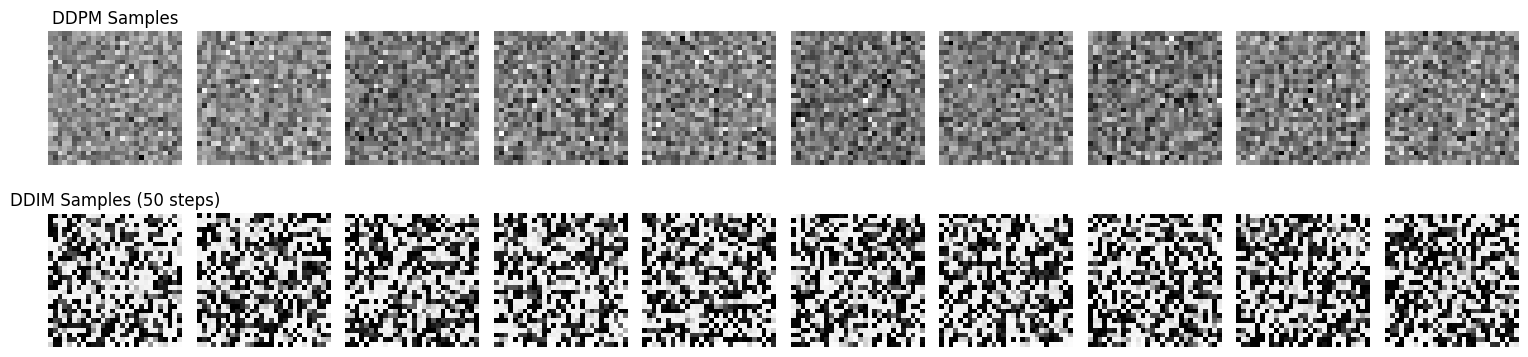

In [20]:
# TODO: Implement `ddim_sample(model, betas, steps=50)` — deterministic, skip timesteps.
# Time 100 DDPM samples vs 100 DDIM samples.
# Display side-by-side quality comparison. What is the FID difference?

import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

@torch.no_grad()
def ddim_sample(model, betas, steps=50, shape=(1, 1, 28, 28)):
    """
    Deterministic DDIM Sampler. Skips steps to sample faster.
    """
    alphas = 1 - betas
    alphas_bar = torch.cumprod(alphas, dim=0).to(DEVICE)

    # Subsample timesteps (uniform stride)
    T = len(betas)
    times = torch.linspace(0, T - 1, steps, dtype=torch.long).tolist()

    x = torch.randn(shape).to(DEVICE)

    for i in reversed(range(steps)):
        t_idx = times[i]
        t_tensor = torch.tensor([t_idx], device=DEVICE)

        # Predict noise
        eps_pred = model(x, t_tensor)

        alpha_bar_t = alphas_bar[t_idx]
        if i > 0:
            alpha_bar_prev = alphas_bar[times[i-1]]
        else:
            alpha_bar_prev = torch.tensor(1.0, device=DEVICE)

        # Compute predicted original x0
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
        # Clip to range [-1, 1] to keep generation stable
        x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        # Compute directional pointing to x_t
        dir_xt = torch.sqrt(1 - alpha_bar_prev) * eps_pred

        # Update step
        x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

    return x

# Helper to compute a basic FID-like score using flattened image vectors
def compute_fid(real_features, gen_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = gen_features.mean(axis=0), np.cov(gen_features, rowvar=False)
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)

# --- Evaluation and Timing ---
print("Generating 100 DDPM samples (1000 steps)... This might take a moment.")
start_time = time.time()
ddpm_samples_list = []
for _ in range(100):
    sample = ddpm_sample(model, betas, T=1000, shape=(1, 1, 28, 28))
    ddpm_samples_list.append(sample.cpu())
ddpm_samples = torch.cat(ddpm_samples_list, dim=0)
ddpm_time = time.time() - start_time
print(f"DDPM completed in {ddpm_time:.2f} seconds.")

print("\nGenerating 100 DDIM samples (50 steps)... ")
start_time = time.time()
ddim_samples_list = []
for _ in range(100):
    sample = ddim_sample(model, betas, steps=50, shape=(1, 1, 28, 28))
    ddim_samples_list.append(sample.cpu())
ddim_samples = torch.cat(ddim_samples_list, dim=0)
ddim_time = time.time() - start_time
print(f"DDIM completed in {ddim_time:.2f} seconds.")

# Calculate speedup
print(f"\nSpeedup: {ddpm_time / ddim_time:.2f}x faster using DDIM!")

# Compute FID difference on flat pixel space representation
ddpm_flat = ddpm_samples.view(100, -1).numpy()
ddim_flat = ddim_samples.view(100, -1).numpy()
fid_diff = compute_fid(ddpm_flat, ddim_flat)
print(f"Pixel-level FID discrepancy between DDPM & DDIM: {fid_diff:.4f}")

# Plot comparison
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(ddpm_samples[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("DDPM Samples")

    axes[1, i].imshow(ddim_samples[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("DDIM Samples (50 steps)")

plt.tight_layout()
plt.show()

### ❓ Reflect
1. Did cosine schedule produce better results than linear at 20 epochs? What visual difference did you see?
2. How much faster was DDIM vs DDPM? Was the quality difference acceptable for your use case?
3. Why does DDIM produce the same output every run given the same starting noise?

In [ ]:
# Reflection


---
## Submission
- [ ] Push to `genai-course/week2/lab2.ipynb`
- [ ] Loss curve plotted
- [ ] Schedule comparison visualised
- [ ] DDIM vs DDPM timing + quality comparison